Allgemeine Ontology bauen

In [6]:
import json

# Load file 
with open("ontology_output/generalized_ontology_per_gcq.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [7]:
# Sets für Duplikatfreies Merging
merged_classes = set()
merged_properties = set()
merged_relationships = set()

In [8]:
# Verarbeitung pro Cluster
for cluster_data in data.values():
    # 🔍 Zugriff auf den echten Pfad zur Ontologie
    ontology = cluster_data.get("generalized_ontology", {}).get("ontology", {})

    if not ontology:
        continue

    merged_classes.update(ontology.get("classes", []))
    merged_properties.update(ontology.get("properties", []))

    for rel in ontology.get("relationships", []):
        if isinstance(rel, list) and len(rel) == 3:
            merged_relationships.add(tuple(rel))  # Set braucht hashable type


In [9]:
# Zusammenbauen der finalen Ontologie
final_ontology = {
    "classes": sorted(merged_classes),
    "properties": sorted(merged_properties),
    "relationships": sorted([list(r) for r in merged_relationships])
}

# Speichern
with open("ontology_output/merged_generalized_ontology.json", "w", encoding="utf-8") as f_out:
    json.dump(final_ontology, f_out, indent=2, ensure_ascii=False)

print("✅ Merged ontology written to 'ontology_output/merged_generalized_ontology.json'")

✅ Merged ontology written to 'ontology_output/merged_generalized_ontology.json'


Visulaisierung allgemeiner Ontology (macht das noch Sinn?) 

Nicht entzerrt

In [ ]:
# Load merged ontology
with open("ontology_output/merged_generalized_ontology.json", "r", encoding="utf-8") as f:
    ontology = json.load(f)

classes = ontology.get("classes", [])
properties = ontology.get("properties", [])
relationships = ontology.get("relationships", [])

# Graph erstellen 
G = nx.DiGraph()
G.add_nodes_from(classes)

for rel in relationships:
    if isinstance(rel, list) and len(rel) == 3:
        subj, pred, obj = rel
        G.add_edge(subj, obj, label=pred)

# Layout 
pos = nx.kamada_kawai_layout(G)

# Plot setup
plt.figure(figsize=(14, 10))
plt.title(" Generalisierte Ontologie – Visualisierung", fontsize=16)

#  Knoten 
nx.draw_networkx_nodes(G, pos, node_color="lightpink", node_size=2000)

# Labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

# Kanten
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True, arrowsize=20)

# Kantenbeschriftungen 
edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, label_pos=0.5)

plt.axis("off")
plt.tight_layout()
plt.show()

entzerrt

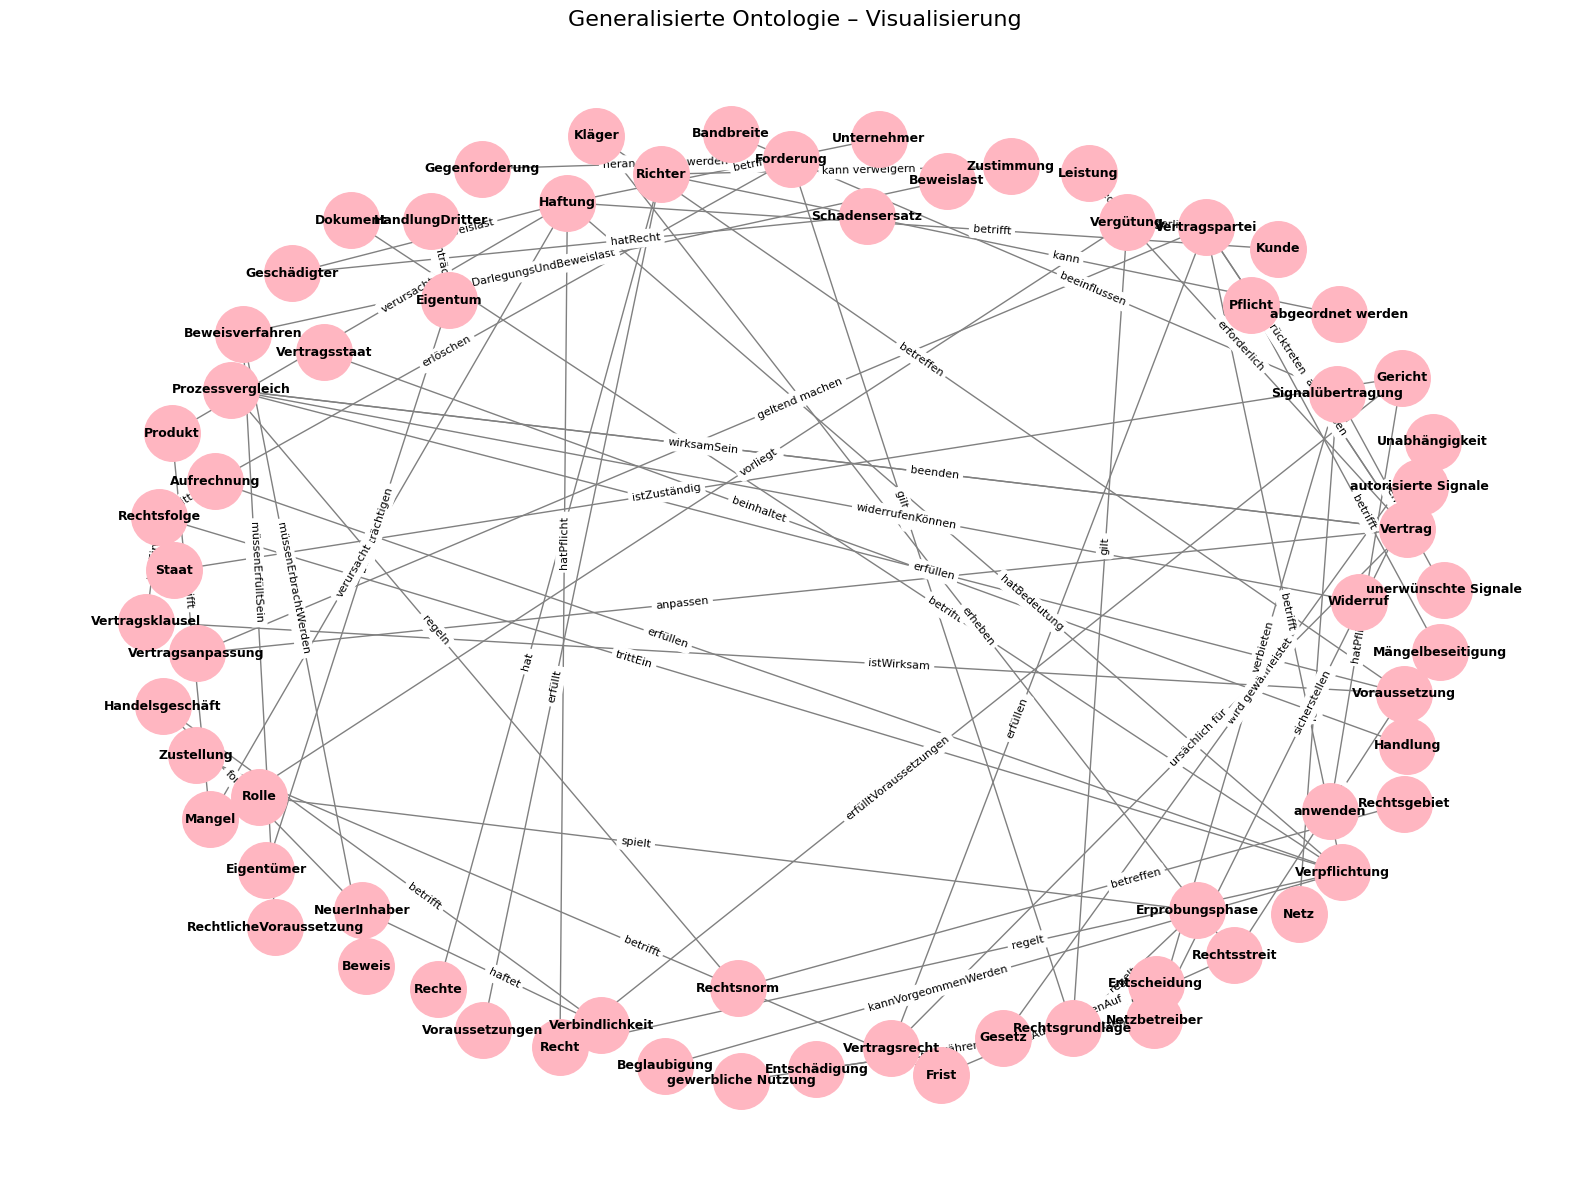

In [13]:
import json
import matplotlib.pyplot as plt
import networkx as nx

# === Load merged ontology ===
with open("ontology_output/merged_generalized_ontology.json", "r", encoding="utf-8") as f:
    ontology = json.load(f)

classes = ontology.get("classes", [])
relationships = ontology.get("relationships", [])

# === Graph erstellen ===
G = nx.DiGraph()

used_classes = set()
for rel in relationships:
    if isinstance(rel, list) and len(rel) == 3:
        subj, pred, obj = rel
        G.add_edge(subj, obj, label=pred)
        used_classes.update([subj, obj])

G.add_nodes_from(used_classes)

# === Entzerrtes Layout ===
pos = nx.spring_layout(G, k=2.5, seed=42)  # k > 1 = mehr Abstand

# === Plot setup ===
plt.figure(figsize=(16, 12))
plt.title("Generalisierte Ontologie – Visualisierung", fontsize=16)

# === Knoten
nx.draw_networkx_nodes(G, pos, node_color="lightpink", node_size=1600)

# === Labels
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

# === Kanten
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True, arrowsize=15)

# === Kantenbeschriftungen
edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.6)

plt.axis("off")
plt.tight_layout()
plt.show()
